# Jacobi 0629 Timing Harness A/B

Compare Jacobi before/after GEMM-style timing hardening at fixed `size=1024`. The notebook intentionally requires both `before` and `after` variants to be present.

In [1]:
from pathlib import Path
import os, re, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATE_BASE = os.environ.get("DATE_BASE", "20260629")
HOST = os.environ.get("HOST", "camd9554n1")
DATA_ROOT = Path(os.environ.get("DATA_ROOT", "/astrum/home/hpchzy/code/data"))
OUTPUT_ROOT = os.environ.get("OUTPUT_ROOT", "output_jacobi_timing_ab_0629_dsub")
RUN_ID = os.environ.get("RUN_ID", "")
NP = int(os.environ.get("NP", "64"))
SIZE = int(os.environ.get("SIZE", "1024"))
NSAMP_RATIO = os.environ.get("NSAMP_RATIO", "0.5")
REF_TIMER = os.environ.get("REF_TIMER", "tsc")
DEFAULT_PLOT_DIR = "plots_0629_jacobi_timing_ab_dsub" if Path.cwd().name == "stencil" else "stencil/plots_0629_jacobi_timing_ab_dsub"
PLOT_DIR = Path(os.environ.get("PLOT_DIR", DEFAULT_PLOT_DIR))
PLOT_DIR.mkdir(parents=True, exist_ok=True)

root = DATA_ROOT / DATE_BASE / HOST / OUTPUT_ROOT
if RUN_ID:
    run_dir = root / RUN_ID
else:
    candidates = sorted([p for p in root.glob("*") if p.is_dir()], key=lambda p: p.stat().st_mtime)
    if not candidates:
        raise FileNotFoundError(f"No run directories under {root}")
    run_dir = candidates[-1]
    RUN_ID = run_dir.name
print("run_dir=", run_dir)
print("plot_dir=", PLOT_DIR)
if not run_dir.exists():
    raise FileNotFoundError(run_dir)


run_dir= /astrum/home/hpchzy/code/data/20260629/camd9554n1/output_jacobi_timing_ab_0629_dsub/20260629-jacobi0629-ab-dsub
plot_dir= plots_0629_jacobi_timing_ab_dsub


In [2]:
def read_time_csv_dir(path: Path, value_col: int):
    vals = []
    for csv in sorted(path.glob("*.csv")):
        try:
            arr = pd.read_csv(csv, header=None).iloc[:, value_col].to_numpy(dtype=float)
            vals.append(arr)
        except Exception as e:
            raise RuntimeError(f"failed reading {csv}: {e}")
    if not vals:
        raise FileNotFoundError(f"no csv files in {path}")
    return np.concatenate(vals)

def read_hist(path: Path):
    df = pd.read_csv(path, header=None, names=["x", "p"], skipinitialspace=True)
    x = df["x"].to_numpy(dtype=float)
    p = df["p"].to_numpy(dtype=float)
    s = p.sum()
    if s <= 0:
        raise ValueError(f"non-positive histogram mass: {path}")
    return x, p / s

def weighted_quantile(x, p, q=0.5):
    order = np.argsort(x)
    x = x[order]
    p = p[order]
    c = np.cumsum(p)
    return float(x[np.searchsorted(c, q, side="left")])

def w1_hist(x1, p1, x2, p2):
    # 1D discrete W1 via integrated CDF distance on union support.
    support = np.unique(np.concatenate([x1, x2]))
    if len(support) < 2:
        return 0.0
    order1 = np.argsort(x1); x1=x1[order1]; p1=p1[order1]
    order2 = np.argsort(x2); x2=x2[order2]; p2=p2[order2]
    c1 = np.array([p1[x1 <= s].sum() for s in support[:-1]])
    c2 = np.array([p2[x2 <= s].sum() for s in support[:-1]])
    dx = np.diff(support)
    return float(np.sum(np.abs(c1 - c2) * dx))

def find_filt_dir(tm_dir: Path):
    matches = sorted(tm_dir.parent.glob(tm_dir.name + f"_nsampRatio{NSAMP_RATIO}_nsamp*_filt"))
    if len(matches) != 1:
        raise FileNotFoundError(f"expected one filt dir for {tm_dir}, found {len(matches)}")
    return matches[0]

def find_tf_dir(tm_dir: Path):
    matches = sorted(tm_dir.parent.glob(tm_dir.name + f"_nsampRatio{NSAMP_RATIO}_nsamp*_tf"))
    if len(matches) != 1:
        raise FileNotFoundError(f"expected one tf dir for {tm_dir}, found {len(matches)}")
    return matches[0]


In [3]:
rows = []
variants = ["before", "after"]
for variant in variants:
    variant_dir = run_dir / variant
    if not variant_dir.exists():
        raise FileNotFoundError(f"missing variant dir: {variant_dir}")
    for shuffle_dir in sorted(variant_dir.glob("shuffle*")):
        shuffle = shuffle_dir.name
        for tm_dir in sorted(shuffle_dir.glob(f"jacobi2d5p_*_np{NP}_size{SIZE}")):
            m = re.match(r"jacobi2d5p_(.+)_np(\d+)_size(\d+)$", tm_dir.name)
            if not m:
                continue
            timer = m.group(1)
            tm_vals = read_time_csv_dir(tm_dir, 1)
            tf_dir = find_tf_dir(tm_dir)
            tf_vals = read_time_csv_dir(tf_dir, 2)
            filt_dir = find_filt_dir(tm_dir)
            tmh_x, tmh_p = read_hist(filt_dir / "tm_hist.csv")
            trh_x, trh_p = read_hist(filt_dir / "tr_hist.csv")
            rows.append({
                "variant": variant,
                "shuffle": shuffle,
                "timer": timer,
                "np": NP,
                "size": SIZE,
                "tm_median_raw_ns": float(np.median(tm_vals)),
                "tf_median_raw_ns": float(np.median(tf_vals)),
                "tm_median_hist_ns": weighted_quantile(tmh_x, tmh_p),
                "tr_median_hist_ns": weighted_quantile(trh_x, trh_p),
                "tm_hist_x": tmh_x,
                "tm_hist_p": tmh_p,
                "tr_hist_x": trh_x,
                "tr_hist_p": trh_p,
            })

df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError("No Jacobi A/B records found")
for variant in variants:
    if variant not in set(df.variant):
        raise RuntimeError(f"Missing variant {variant}")
print(df[["variant","shuffle","timer","tm_median_raw_ns","tf_median_raw_ns","tr_median_hist_ns"]].sort_values(["variant","shuffle","timer"]).to_string(index=False))


variant  shuffle      timer  tm_median_raw_ns  tf_median_raw_ns  tr_median_hist_ns
  after shuffle0        cgt            4747.0            4787.0             4621.0
  after shuffle0       papi            4848.0            5479.0             4151.0
  after shuffle0     papix6            4848.0            5488.0             4103.0
  after shuffle0        tsc            4747.0            4777.0             4691.0
  after shuffle0 tsc_native            5267.0            5297.0             5141.0
  after shuffle0      wtime            4627.0            4667.0             4570.0
  after shuffle1        cgt            4737.0            4777.0             4631.0
  after shuffle1       papi            4858.0            5489.0             4161.0
  after shuffle1     papix6            4857.0            5498.0             4111.0
  after shuffle1        tsc            4717.0            4747.0             4601.0
  after shuffle1 tsc_native            5267.0            5297.0             5141.0
  af

In [4]:
# Add divergence to reference timer within each variant/shuffle.
div_rows = []
for (variant, shuffle), g in df.groupby(["variant", "shuffle"]):
    ref = g[g.timer == REF_TIMER]
    if ref.empty:
        print(f"skip divergence for {variant}/{shuffle}: missing {REF_TIMER}")
        continue
    ref = ref.iloc[0]
    for _, r in g.iterrows():
        div_rows.append({
            "variant": variant,
            "shuffle": shuffle,
            "timer": r.timer,
            "tm_w1_to_ref_ns": w1_hist(r.tm_hist_x, r.tm_hist_p, ref.tm_hist_x, ref.tm_hist_p),
            "tr_w1_to_ref_ns": w1_hist(r.tr_hist_x, r.tr_hist_p, ref.tr_hist_x, ref.tr_hist_p),
        })
div = pd.DataFrame(div_rows)
metrics = df.drop(columns=["tm_hist_x","tm_hist_p","tr_hist_x","tr_hist_p"]).merge(div, how="left", on=["variant","shuffle","timer"])
metrics.to_csv(PLOT_DIR / f"jacobi0629_ab_metrics_{HOST}_{RUN_ID}.csv", index=False)
metrics.sort_values(["variant","shuffle","timer"]).head(20)


,variant,shuffle,timer,np,size,tm_median_raw_ns,tf_median_raw_ns,tm_median_hist_ns,tr_median_hist_ns,tm_w1_to_ref_ns,tr_w1_to_ref_ns
18,after,shuffle0,cgt,64,1024,4747.0,4787.0,4731.0,4621.0,27.800151,36.760191
19,after,shuffle0,papi,64,1024,4848.0,5479.0,4842.0,4151.0,139.801026,504.014782
20,after,shuffle0,papix6,64,1024,4848.0,5488.0,4803.0,4103.0,148.498815,582.338223
22,after,shuffle0,tsc,64,1024,4747.0,4777.0,4721.0,4691.0,0.000000,0.000000
21,after,shuffle0,tsc_native,64,1024,5267.0,5297.0,5251.0,5141.0,511.417971,453.316826
23,after,shuffle0,wtime,64,1024,4627.0,4667.0,4610.0,4570.0,180.115096,175.046170
24,after,shuffle1,cgt,64,1024,4737.0,4777.0,4671.0,4631.0,48.010137,47.001029
25,after,shuffle1,papi,64,1024,4858.0,5489.0,4852.0,4161.0,176.278722,473.725210
26,after,shuffle1,papix6,64,1024,4857.0,5498.0,4812.0,4111.0,170.891585,539.640597
28,after,shuffle1,tsc,64,1024,4717.0,4747.0,4701.0,4601.0,0.000000,0.000000


In [5]:
summary = metrics.groupby(["variant","timer"]).agg(
    tm_median_ns=("tm_median_raw_ns", "median"),
    tr_median_ns=("tr_median_hist_ns", "median"),
    tf_median_ns=("tf_median_raw_ns", "median"),
    tm_shuffle_cv=("tm_median_raw_ns", lambda x: float(np.std(x, ddof=1) / np.mean(x)) if len(x) > 1 else 0.0),
    tr_shuffle_cv=("tr_median_hist_ns", lambda x: float(np.std(x, ddof=1) / np.mean(x)) if len(x) > 1 else 0.0),
    tm_w1_to_ref_ns=("tm_w1_to_ref_ns", "median"),
    tr_w1_to_ref_ns=("tr_w1_to_ref_ns", "median"),
).reset_index()

ref = summary[summary.timer == REF_TIMER][["variant","tm_median_ns","tr_median_ns"]].rename(columns={"tm_median_ns":"ref_tm","tr_median_ns":"ref_tr"})
summary = summary.merge(ref, on="variant", how="left")
summary["tm_ratio_to_ref"] = summary["tm_median_ns"] / summary["ref_tm"]
summary["tr_ratio_to_ref"] = summary["tr_median_ns"] / summary["ref_tr"]
summary.to_csv(PLOT_DIR / f"jacobi0629_ab_summary_{HOST}_{RUN_ID}.csv", index=False)
print(summary.sort_values(["variant","timer"]).to_string(index=False))

spread = summary.groupby("variant").agg(
    tm_timer_spread_ratio=("tm_ratio_to_ref", lambda x: float(np.nanmax(x) - np.nanmin(x))),
    tr_timer_spread_ratio=("tr_ratio_to_ref", lambda x: float(np.nanmax(x) - np.nanmin(x))),
    median_tm_shuffle_cv=("tm_shuffle_cv", "median"),
    median_tr_shuffle_cv=("tr_shuffle_cv", "median"),
    median_tm_w1_to_ref_ns=("tm_w1_to_ref_ns", "median"),
    median_tr_w1_to_ref_ns=("tr_w1_to_ref_ns", "median"),
).reset_index()
spread.to_csv(PLOT_DIR / f"jacobi0629_ab_spread_{HOST}_{RUN_ID}.csv", index=False)
print("\nA/B spread/stability:")
print(spread.to_string(index=False))


variant      timer  tm_median_ns  tr_median_ns  tf_median_ns  tm_shuffle_cv  tr_shuffle_cv  tm_w1_to_ref_ns  tr_w1_to_ref_ns  ref_tm  ref_tr  tm_ratio_to_ref  tr_ratio_to_ref
  after        cgt        4737.0        4631.0        4777.0       0.002111       0.001248        44.214931        47.001029  4747.0  4681.0         0.997893         0.989319
  after       papi        4858.0        4151.0        5489.0       0.001957       0.002409       151.539538       487.242411  4747.0  4681.0         1.023383         0.886776
  after     papix6        4857.0        4111.0        5498.0       0.001957       0.002193       148.498815       582.338223  4747.0  4681.0         1.023173         0.878231
  after        tsc        4747.0        4681.0        4777.0       0.003656       0.010591         0.000000         0.000000  4747.0  4681.0         1.000000         1.000000
  after tsc_native        5267.0        5141.0        5297.0       0.002190       0.000000       543.343232       482.435947 

plots_0629_jacobi_timing_ab_dsub/jacobi0629_ab_tm_tr_ratio_camd9554n1_20260629-jacobi0629-ab-dsub.png


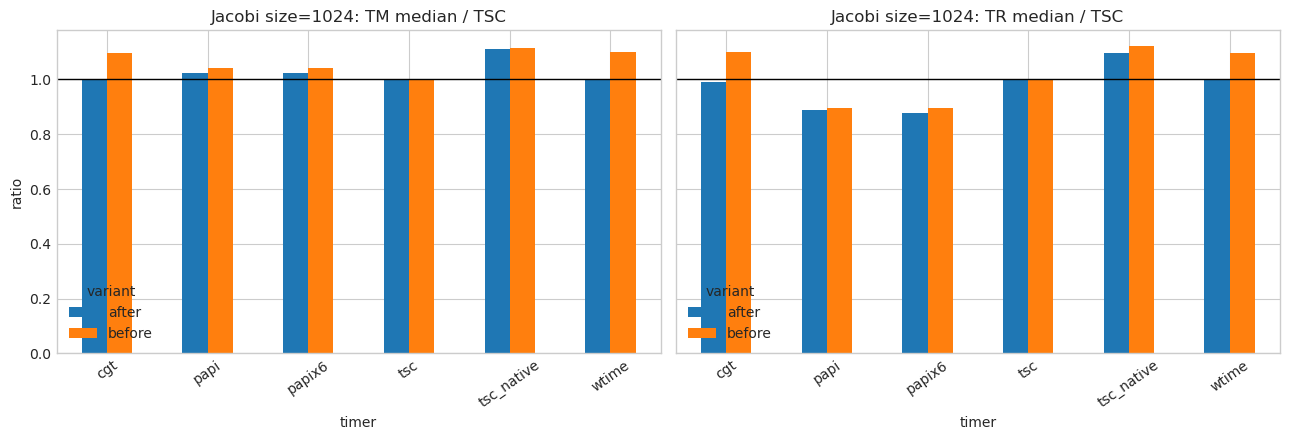

plots_0629_jacobi_timing_ab_dsub/jacobi0629_ab_shuffle_cv_camd9554n1_20260629-jacobi0629-ab-dsub.png


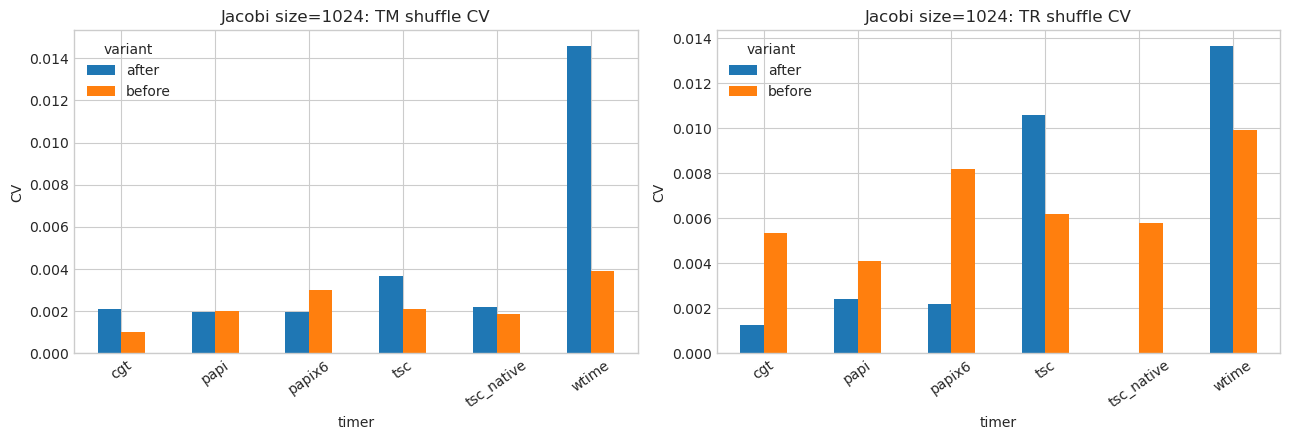

plots_0629_jacobi_timing_ab_dsub/jacobi0629_ab_w1_camd9554n1_20260629-jacobi0629-ab-dsub.png


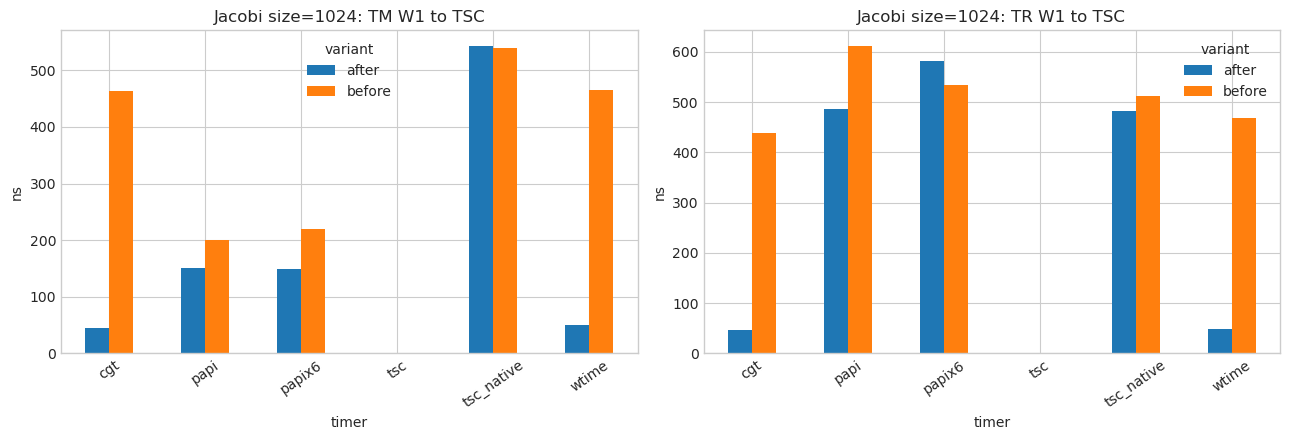

In [6]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, metric, title in zip(axes, ["tm_ratio_to_ref", "tr_ratio_to_ref"], ["TM median / TSC", "TR median / TSC"]):
    pivot = summary.pivot(index="timer", columns="variant", values=metric).sort_index()
    pivot.plot(kind="bar", ax=ax)
    ax.axhline(1.0, color="black", linewidth=1)
    ax.set_title(f"Jacobi size={SIZE}: {title}")
    ax.set_xlabel("timer")
    ax.set_ylabel("ratio")
    ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
out = PLOT_DIR / f"jacobi0629_ab_tm_tr_ratio_{HOST}_{RUN_ID}.png"
fig.savefig(out, dpi=180)
print(out)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric, title in zip(axes, ["tm_shuffle_cv", "tr_shuffle_cv"], ["TM shuffle CV", "TR shuffle CV"]):
    pivot = summary.pivot(index="timer", columns="variant", values=metric).sort_index()
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"Jacobi size={SIZE}: {title}")
    ax.set_xlabel("timer")
    ax.set_ylabel("CV")
    ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
out = PLOT_DIR / f"jacobi0629_ab_shuffle_cv_{HOST}_{RUN_ID}.png"
fig.savefig(out, dpi=180)
print(out)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric, title in zip(axes, ["tm_w1_to_ref_ns", "tr_w1_to_ref_ns"], ["TM W1 to TSC", "TR W1 to TSC"]):
    pivot = summary.pivot(index="timer", columns="variant", values=metric).sort_index()
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"Jacobi size={SIZE}: {title}")
    ax.set_xlabel("timer")
    ax.set_ylabel("ns")
    ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
out = PLOT_DIR / f"jacobi0629_ab_w1_{HOST}_{RUN_ID}.png"
fig.savefig(out, dpi=180)
print(out)
plt.show()
